In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv(r'/Users/user/Documents/Data Analysis Projects/Customer Revenue Leakage Analysis/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [6]:
#Data Cleaning and Trandformation
data_shape_col = df.shape[1]
data_shape_row = df.shape[0]

data_missing = df.isna().sum().sum()
data_duplicate = df.duplicated().sum()
data_type = df.dtypes

print(f'This dataset has {data_shape_col} columns and {data_shape_row} rows') 
print(f'This dataset has {data_missing} missing values')
print(f'This dataet has {data_duplicate} duplicates \n') 

print(f'Dataset Datatypes:\n{data_type}')

This dataset has 21 columns and 7043 rows
This dataset has 0 missing values
This dataet has 0 duplicates 

Dataset Datatypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [7]:
#Changing No phone service across the column(Multiple line)
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [8]:
#Changing No Internet service across the column
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df[internet_cols]= df[internet_cols].replace('No internet service', 'No')


In [9]:
df['MultipleLines'].unique().sum()

'NoYes'

In [10]:
df['OnlineBackup'].unique().sum()

'YesNo'

In [11]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1:'Yes', 0:'No'})

In [12]:
df['SeniorCitizen'].unique().sum()

'NoYes'

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
#Checking the datatypes again
data_missing2 = df.isna().sum().sum()
data_duplicate2 = df.duplicated().sum()
data_type2 = df.dtypes

print(f'This dataset has {data_missing2} missing values')
print(f'This dataet has {data_duplicate2} duplicates \n') 

print(f'Dataset Datatypes:\n{data_type2}')

This dataset has 11 missing values
This dataet has 0 duplicates 

Dataset Datatypes:
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [19]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [54]:
#Exploratory data analysis (EDA)

#Customer Overview
#total customers
total_customers = df['customerID'].nunique()
#Average tenure 
average_tenure = df['tenure'].mean()
#Average Monthly revenue
avg_monthly_revenue = df['MonthlyCharges'].mean()
#churn rate
churn_rate = (df['Churn'] == 'Yes').mean()*100

print(f"The total customer are {total_customers} people \n")
print(f"The average tenure of customer is {average_tenure: .2f} months \n")
print(f"The average monthly revenue is ${avg_monthly_revenue: .2f} \n")
print(f"The overall churn rate is {churn_rate: .2f}%")

The total customer are 7043 people 

The average tenure of customer is  32.37 months 

The average monthly revenue is $ 64.76 

The overall churn rate is  26.54%


The Average monthly charges is $ 64.76 

The Total Revenue Generated is $ 16056168.70



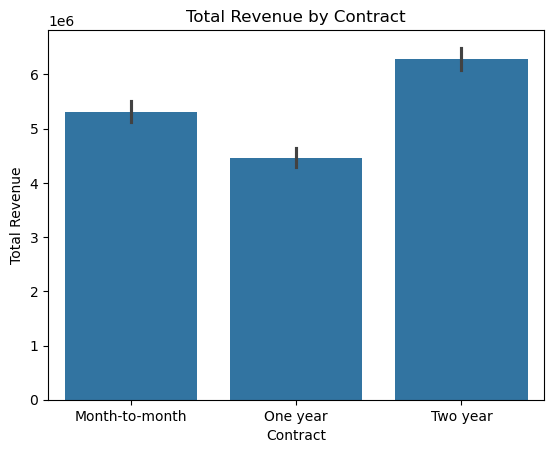

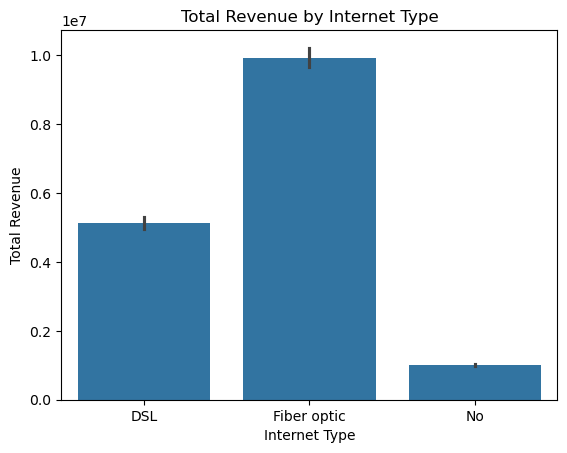

In [55]:
#Revnue Overview
#Average Monthly Charges
avg_monthly_charges = df['MonthlyCharges'].mean()
#Total Revenue
total_revenue = df['TotalCharges'].sum()

print(f"The Average monthly charges is ${avg_monthly_charges: .2f} \n")
print(f"The Total Revenue Generated is ${total_revenue: .2f}\n")
#Revenue By Contract
# Barplot of Total Charges by Contract Type
sns.barplot(data=df,
            x= 'Contract', 
            y='TotalCharges',
            estimator= 'sum'
           )
plt.title('Total Revenue by Contract')
plt.xlabel('Contract')
plt.ylabel('Total Revenue')
plt.show()
#Revenue By Internet Service
# Barplot of Total Charges by Internet Service
sns.barplot(data=df,
            x= 'InternetService', 
            y='TotalCharges',
            estimator= 'sum'
           )
plt.title('Total Revenue by Internet Type')
plt.xlabel('Internet Type')
plt.ylabel('Total Revenue')
plt.show()

         Contract  ChurnRate (%)
0  Month-to-month      42.709677
1        One year      11.269518
2        Two year       2.831858


/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/3191997807.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_contract,


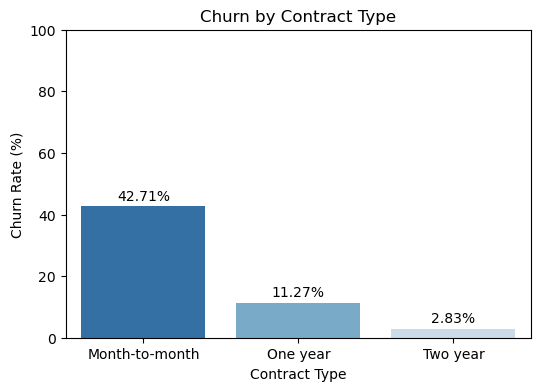

In [56]:
#Churn Analysis
#churn by Contract
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
churn_by_contract.columns = ['Contract', 'ChurnRate (%)']
print(churn_by_contract)

plt.figure(figsize =(6,4))
sns.barplot(data=churn_by_contract,
            x= 'Contract',
            y= 'ChurnRate (%)',
            palette= 'Blues_r'
           )
plt.title('Churn by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.ylim(0, 100)

for index, row in churn_by_contract.iterrows():
    plt.text(index, row['ChurnRate (%)'] + 2, f"{row['ChurnRate (%)']:.2f}%", ha='center')

plt.show()

         Contract  ChurnRate (%)
0  Month-to-month      42.709677
1        One year      11.269518
2        Two year       2.831858


/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/1494663349.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_internet,


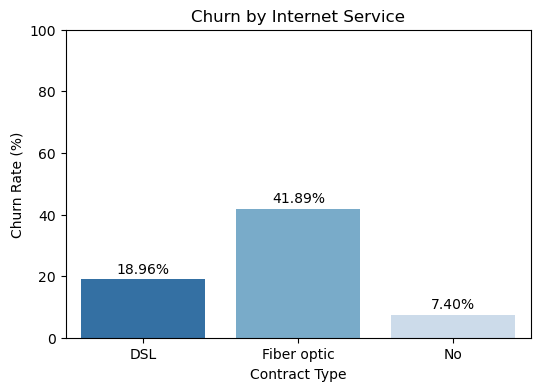

In [57]:
#Churn Analysis
#churn by Internet Service
churn_by_internet = df.groupby('InternetService')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
churn_by_internet.columns = ['InternetService', 'ChurnRate (%)']
print(churn_by_contract)

plt.figure(figsize =(6,4))
sns.barplot(data=churn_by_internet,
            x= 'InternetService',
            y= 'ChurnRate (%)',
            palette= 'Blues_r'
           )
plt.title('Churn by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.ylim(0, 100)

for index, row in churn_by_internet.iterrows():
    plt.text(index, row['ChurnRate (%)'] + 2, f"{row['ChurnRate (%)']:.2f}%", ha='center')

plt.show()

         Contract  ChurnRate (%)
0  Month-to-month      42.709677
1        One year      11.269518
2        Two year       2.831858


/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/2475164722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_payment,


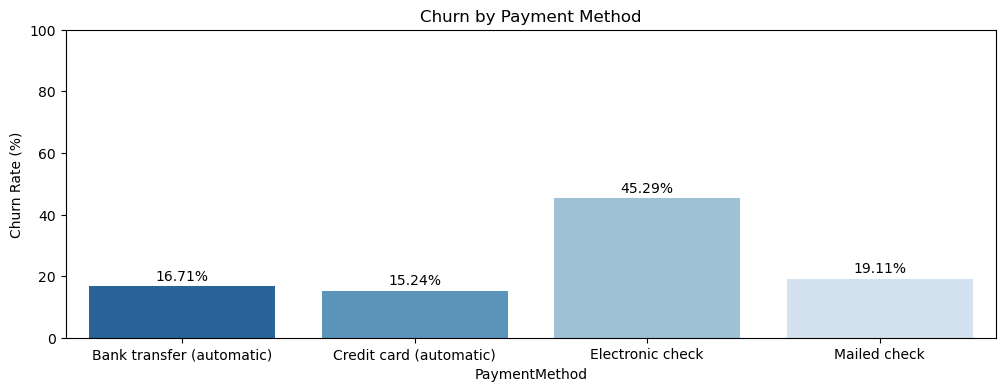

In [58]:
#Churn Analysis
#churn by Payment Methos
churn_by_payment = df.groupby('PaymentMethod')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
churn_by_payment.columns = ['PaymentMethod', 'ChurnRate (%)']
print(churn_by_contract)

plt.figure(figsize =(12,4))
sns.barplot(data=churn_by_payment,
            x= 'PaymentMethod',
            y= 'ChurnRate (%)',
            palette= 'Blues_r'
           )
plt.title('Churn by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

for index, row in churn_by_payment.iterrows():
    plt.text(index, row['ChurnRate (%)'] + 2, f"{row['ChurnRate (%)']:.2f}%", ha='center')

plt.show()

In [59]:
#Feature Engineering
#Tenure groups
tenure_labels = ['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72], labels=tenure_labels)

#Monthly Charge Segments
df['MonthlyChargeSegment'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low Spend', 'Medium Spend', 'High Spend'])

#Revenue Segments
df['RevenueSegment']= pd.cut(
    df['TotalCharges'], 
    bins = [0, 4000, 8000, df['TotalCharges'].max()],
    labels=['Low Revenue', 'Medium Revenue', 'High Revenue']
)

print(df[['tenure', 'TenureGroup', 'MonthlyCharges', 'MonthlyChargeSegment', 'RevenueSegment']].head())

   tenure TenureGroup  MonthlyCharges MonthlyChargeSegment RevenueSegment
0       1    0-1 Year           29.85            Low Spend    Low Revenue
1      34   2-4 Years           56.95         Medium Spend    Low Revenue
2       2    0-1 Year           53.85         Medium Spend    Low Revenue
3      45   2-4 Years           42.30            Low Spend    Low Revenue
4       2    0-1 Year           70.70         Medium Spend    Low Revenue


  TenureGroup  ChurnRate (%)
0    0-1 Year      47.438243
1   1-2 Years      28.710938
2   2-4 Years      20.388959
3   4-6 Years       9.513176


/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/3592070541.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('TenureGroup')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/3592070541.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_tenure,


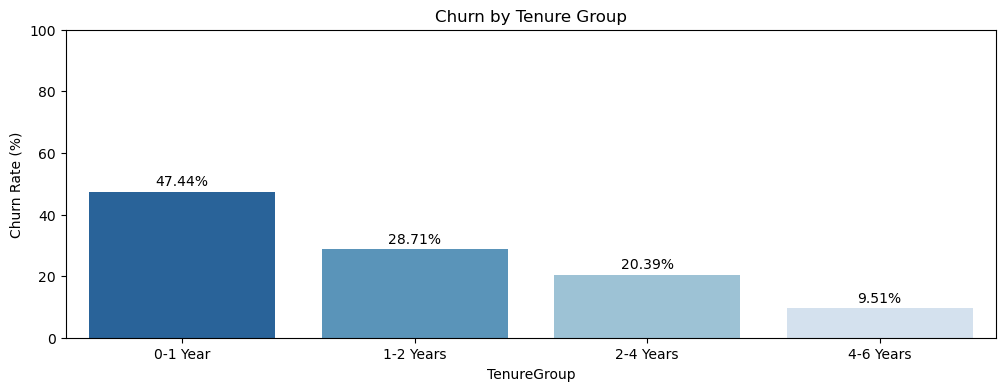

In [60]:
#Churn Analysis
#churn by Payment Methos
churn_by_tenure = df.groupby('TenureGroup')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
churn_by_tenure.columns = ['TenureGroup', 'ChurnRate (%)']
print(churn_by_tenure)

plt.figure(figsize =(12,4))
sns.barplot(data=churn_by_tenure,
            x= 'TenureGroup',
            y= 'ChurnRate (%)',
            palette= 'Blues_r'
           )
plt.title('Churn by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

for index, row in churn_by_tenure.iterrows():
    plt.text(index, row['ChurnRate (%)'] + 2, f"{row['ChurnRate (%)']:.2f}%", ha='center')

plt.show()

  TenureGroup  ChurnRate (%)
0    0-1 Year      47.438243
1   1-2 Years      28.710938
2   2-4 Years      20.388959
3   4-6 Years       9.513176


/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/375011013.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_monthly_charge = df.groupby('MonthlyChargeSegment')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
/var/folders/w4/kjk06sm57pq_gvhqvdzmgjsw0000gn/T/ipykernel_8595/375011013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_monthly_charge,


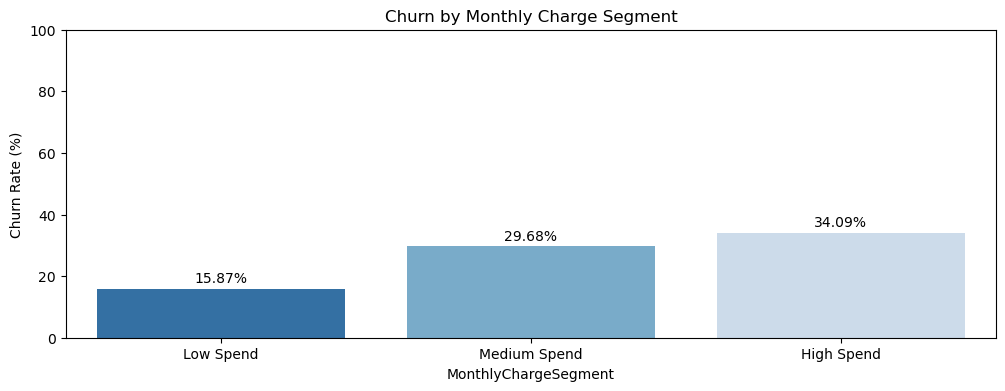

In [61]:
#Churn Analysis
#churn by Payment Methos
churn_by_monthly_charge = df.groupby('MonthlyChargeSegment')['Churn'].apply(lambda x:(x=='Yes').mean() * 100).reset_index()
churn_by_monthly_charge.columns = ['MonthlyChargeSegment', 'ChurnRate (%)']
print(churn_by_tenure)

plt.figure(figsize =(12,4))
sns.barplot(data=churn_by_monthly_charge,
            x= 'MonthlyChargeSegment',
            y= 'ChurnRate (%)',
            palette= 'Blues_r'
           )
plt.title('Churn by Monthly Charge Segment')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

for index, row in churn_by_monthly_charge.iterrows():
    plt.text(index, row['ChurnRate (%)'] + 2, f"{row['ChurnRate (%)']:.2f}%", ha='center')

plt.show()

In [62]:
#Correlation Analysis
#Copying the data inorder not to affect the original

df_corr = df.copy()

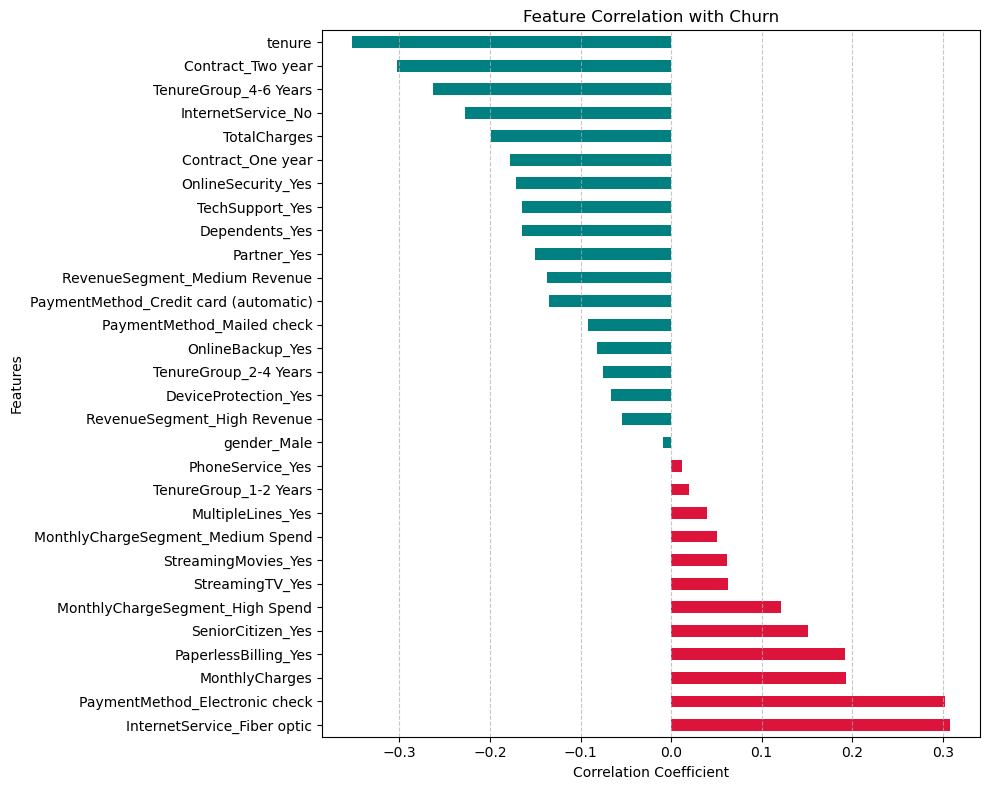

Top Positive Correlations (Increases Churn Risk):
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen_Yes                 0.150889
Name: Churn, dtype: float64

Top Negative Correlations (Decreases Churn Risk):
TotalCharges            -0.198324
InternetService_No      -0.227890
TenureGroup_4-6 Years   -0.263222
Contract_Two year       -0.302253
tenure                  -0.352229
Name: Churn, dtype: float64


In [63]:
#Converting the Churn booleans to numeric
df_corr['Churn'] = df_corr['Churn'].apply(lambda x: 1 if x =='Yes' else 0)

#Drop non-predictive IDs or unencoded categorical objects
# One-hot encode remaining categorical features
df_encoded = pd.get_dummies(df_corr.drop(columns=['customerID'], errors='ignore'), drop_first=True)

churn_corr = df_encoded.corr()['Churn'].sort_values(ascending=False).drop('Churn')

plt.figure(figsize=(10, 8))
churn_corr.plot(kind='barh', color=np.where(churn_corr > 0, 'crimson', 'teal'))
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print top positive and negative correlations
print("Top Positive Correlations (Increases Churn Risk):")
print(churn_corr.head(5))

print("\nTop Negative Correlations (Decreases Churn Risk):")
print(churn_corr.tail(5))

In [65]:
df.to_csv(r'/Users/user/Documents/Data Analysis Projects/Customer Revenue Leakage Analysis/Clean IBM Teleco data.csv')